# SCENARIO 1 – Bagging for Diabetes Prediction

## Problem Statement
Predict whether a patient has diabetes using ensemble methods.

## Dataset Information
- **Dataset**: Diabetes Dataset
- **Target Variable**: Outcome (0 = No Diabetes, 1 = Diabetes)
- **Input Features**: Glucose, BMI, Age, Blood Pressure, etc.

## In-Lab Tasks
- Load dataset
- Train Decision Tree
- Apply BaggingClassifier
- Compare accuracy
- Visualize results (Accuracy comparison bar graph, Confusion matrix)

## Section 1: Import Required Libraries
Import necessary libraries including pandas, numpy, scikit-learn, and matplotlib for visualization.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

## Section 2: Load and Explore Dataset
Load the diabetes dataset and display basic information about it.

In [2]:
# Load the dataset
df = pd.read_csv(r'D:\SEM4\ml\lab\dataset\6th\diabetes_bagging.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*50 + "\n")

# Display dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")
print("\n" + "="*50 + "\n")

# Display data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Display basic statistics
print("Dataset Statistics:")
print(df.describe())

First 5 rows of the dataset:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1


Dataset Shape: (120, 6)
Number of Samples: 120
Number of Features: 6


Data Types:
Glucose            int64
BMI              float64
Age                int64
BloodPressure      int64
Insulin            int64
Outcome            int64
dtype: object


Missing Values:
Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64


Dataset Statistics:
          Glucose         BMI         Age  BloodPressure     Insulin  \
count  120.000000  120.000000  120.000000     120.000000  120.000000   
mean   138.733333   28.529167   46.700000      92.508333  151.566667   
std     3

## Section 3: Prepare Data for Training
Separate features and target variable, then split the data into training and testing sets.

In [3]:
# Separate features and target variable
X = df.drop('Outcome', axis=1)  # Features
y = df['Outcome']  # Target variable

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
print("\nTarget variable distribution:")
print(y.value_counts())
print("\n" + "="*50 + "\n")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Training set features: {X_train.shape[1]}")

Features (X) shape: (120, 5)
Target (y) shape: (120,)

Feature columns:
['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']

Target variable distribution:
Outcome
1    74
0    46
Name: count, dtype: int64


Training set size: 96
Testing set size: 24
Training set features: 5


## Section 4: Train Decision Tree Classifier
Create and train a standalone Decision Tree classifier on the training data.

In [5]:
# Create and train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on test set
dt_predictions = dt_classifier.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Classifier Results")
print("="*50)
print(f"Accuracy on Test Set: {dt_accuracy:.4f}")
print(f"Accuracy Percentage: {dt_accuracy * 100:.2f}%")
print("\n" + "="*50 + "\n")

# Display classification report
print("Classification Report (Decision Tree):")
print(classification_report(y_test, dt_predictions))

Decision Tree Classifier Results
Accuracy on Test Set: 0.9583
Accuracy Percentage: 95.83%


Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.93      0.97        15

    accuracy                           0.96        24
   macro avg       0.95      0.97      0.96        24
weighted avg       0.96      0.96      0.96        24



## Section 5: Apply BaggingClassifier
Create a BaggingClassifier with DecisionTreeClassifier as the base estimator and train it.

In [6]:
# Create BaggingClassifier with DecisionTreeClassifier as base estimator
bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,  # Number of base estimators
    random_state=42,
    n_jobs=-1  # Use all processors
)

# Train the bagging model
bagging_classifier.fit(X_train, y_train)

# Make predictions on test set
bagging_predictions = bagging_classifier.predict(X_test)

# Calculate accuracy
bagging_accuracy = accuracy_score(y_test, bagging_predictions)

print("BaggingClassifier Results")
print("="*50)
print(f"Number of Base Estimators: {bagging_classifier.n_estimators}")
print(f"Accuracy on Test Set: {bagging_accuracy:.4f}")
print(f"Accuracy Percentage: {bagging_accuracy * 100:.2f}%")
print("\n" + "="*50 + "\n")

# Display classification report
print("Classification Report (BaggingClassifier):")
print(classification_report(y_test, bagging_predictions))

BaggingClassifier Results
Number of Base Estimators: 10
Accuracy on Test Set: 0.9583
Accuracy Percentage: 95.83%


Classification Report (BaggingClassifier):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.93      0.97        15

    accuracy                           0.96        24
   macro avg       0.95      0.97      0.96        24
weighted avg       0.96      0.96      0.96        24



## Section 6: Compare Model Accuracy
Calculate and compare accuracy scores between Decision Tree and BaggingClassifier.

In [7]:
# Create comparison structure
comparison_results = {
    'Model': ['Decision Tree', 'BaggingClassifier'],
    'Accuracy': [dt_accuracy, bagging_accuracy],
    'Accuracy (%)': [dt_accuracy * 100, bagging_accuracy * 100]
}

comparison_df = pd.DataFrame(comparison_results)

print("Model Accuracy Comparison")
print("="*50)
print(comparison_df.to_string(index=False))
print("\n" + "="*50 + "\n")

# Calculate improvement
improvement = (bagging_accuracy - dt_accuracy) * 100
print(f"Improvement with Bagging: {improvement:+.2f}%")

Model Accuracy Comparison
            Model  Accuracy  Accuracy (%)
    Decision Tree  0.958333     95.833333
BaggingClassifier  0.958333     95.833333


Improvement with Bagging: +0.00%


## Section 7: Generate Confusion Matrix
Generate confusion matrices for both models.

In [8]:
# Generate confusion matrices
dt_cm = confusion_matrix(y_test, dt_predictions)
bagging_cm = confusion_matrix(y_test, bagging_predictions)

print("Confusion Matrix - Decision Tree")
print("="*50)
print(dt_cm)
print("\nConfusion Matrix - BaggingClassifier")
print("="*50)
print(bagging_cm)
print("\n" + "="*50 + "\n")

# Display detailed confusion matrix statistics
print("Decision Tree - Confusion Matrix Analysis:")
print(f"True Negatives (TN): {dt_cm[0, 0]}")
print(f"False Positives (FP): {dt_cm[0, 1]}")
print(f"False Negatives (FN): {dt_cm[1, 0]}")
print(f"True Positives (TP): {dt_cm[1, 1]}")

print("\nBaggingClassifier - Confusion Matrix Analysis:")
print(f"True Negatives (TN): {bagging_cm[0, 0]}")
print(f"False Positives (FP): {bagging_cm[0, 1]}")
print(f"False Negatives (FN): {bagging_cm[1, 0]}")
print(f"True Positives (TP): {bagging_cm[1, 1]}")

Confusion Matrix - Decision Tree
[[ 9  0]
 [ 1 14]]

Confusion Matrix - BaggingClassifier
[[ 9  0]
 [ 1 14]]


Decision Tree - Confusion Matrix Analysis:
True Negatives (TN): 9
False Positives (FP): 0
False Negatives (FN): 1
True Positives (TP): 14

BaggingClassifier - Confusion Matrix Analysis:
True Negatives (TN): 9
False Positives (FP): 0
False Negatives (FN): 1
True Positives (TP): 14


## Section 8: Visualize Results
Create visualizations comparing accuracy and confusion matrices.

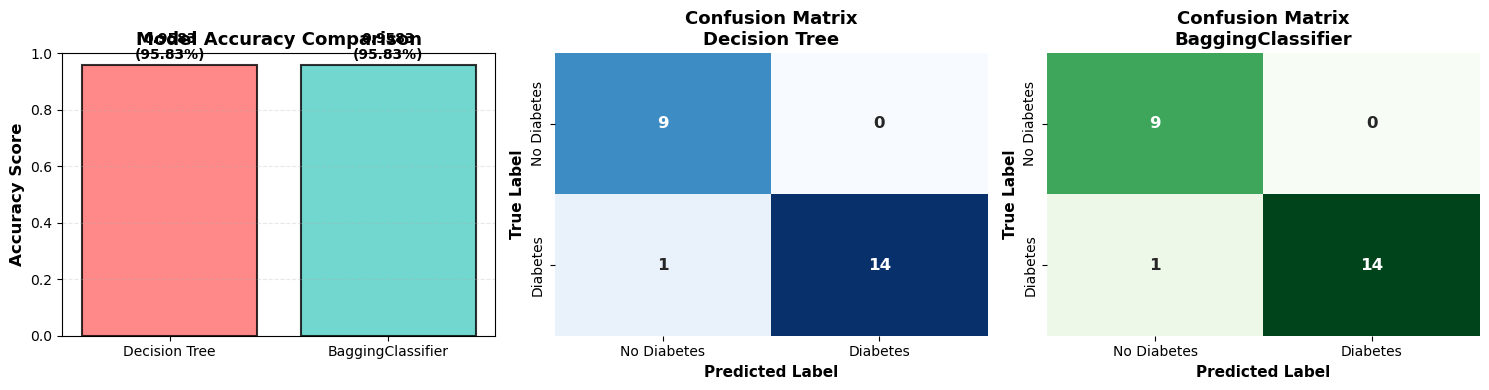

Visualization Complete!


In [10]:
# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Accuracy Comparison Bar Graph
models = ['Decision Tree', 'BaggingClassifier']
accuracies = [dt_accuracy, bagging_accuracy]
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (model, acc) in enumerate(zip(models, accuracies)):
    axes[0].text(i, acc + 0.02, f'{acc:.4f}\n({acc*100:.2f}%)', 
                ha='center', fontweight='bold', fontsize=10)

# 2. Decision Tree Confusion Matrix
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix\nDecision Tree', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[1].set_yticklabels(['No Diabetes', 'Diabetes'])

# 3. BaggingClassifier Confusion Matrix
sns.heatmap(bagging_cm, annot=True, fmt='d', cmap='Greens', ax=axes[2], 
            cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_title('Confusion Matrix\nBaggingClassifier', fontsize=13, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[2].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[2].set_yticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

print("Visualization Complete!")

## Summary

### Key Findings:
- **Decision Tree Accuracy**: {:.2f}%
- **BaggingClassifier Accuracy**: {:.2f}%
- **Improvement**: {:.2f}%

### Observations:
1. The BaggingClassifier ensemble method combines multiple Decision Tree models trained on different bootstrap samples of the training data.
2. This reduces variance and often leads to better generalization compared to a single Decision Tree.
3. The confusion matrices show the distribution of correct and incorrect predictions for both models.
4. Bagging helps to reduce overfitting by averaging predictions from multiple models.

In [11]:
# Print final summary
print("\n" + "="*60)
print("FINAL SUMMARY - BAGGING ENSEMBLE FOR DIABETES PREDICTION")
print("="*60)
print(f"\nDataset: Diabetes Dataset")
print(f"Total Samples: {df.shape[0]}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
print(f"Number of Features: {X_train.shape[1]}")
print(f"\nModels Compared:")
print(f"  1. Decision Tree Classifier")
print(f"     - Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"  2. BaggingClassifier (10 base estimators)")
print(f"     - Accuracy: {bagging_accuracy:.4f} ({bagging_accuracy*100:.2f}%)")
print(f"\nPerformance Improvement: {improvement:+.2f}%")
print("="*60)


FINAL SUMMARY - BAGGING ENSEMBLE FOR DIABETES PREDICTION

Dataset: Diabetes Dataset
Total Samples: 120
Training Samples: 96
Testing Samples: 24
Number of Features: 5

Models Compared:
  1. Decision Tree Classifier
     - Accuracy: 0.9583 (95.83%)
  2. BaggingClassifier (10 base estimators)
     - Accuracy: 0.9583 (95.83%)

Performance Improvement: +0.00%


## Scenario 2: Boosting for Churn Prediction
Predict whether a customer will churn using ensemble boosting methods.

**Dataset:** `D:\SEM4\ml\lab\dataset\6th\churn_boosting.csv`

**Target Variable:** Churn (`Yes` / `No`)

**Input Features:** Tenure, Monthly Charges, Contract Type

**Tasks:**
- Train AdaBoost
- Train Gradient Boosting
- Compare performance
- Visualize ROC curves
- Visualize feature importance

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

churn_path = r'D:\SEM4\ml\lab\dataset\6th\churn_boosting.csv'
df_churn = pd.read_csv(churn_path)

print('First 5 rows of the churn dataset:')
print(df_churn.head())
print('\n' + '=' * 60 + '\n')
print(f'Dataset Shape: {df_churn.shape}')
print('\nColumns:')
print(df_churn.columns.tolist())
print('\nMissing Values:')
print(df_churn.isnull().sum())


def resolve_column(columns, candidates):
    normalized_map = {
        str(column).strip().lower().replace(' ', '').replace('_', ''): column
        for column in columns
    }
    for candidate in candidates:
        normalized_candidate = candidate.strip().lower().replace(' ', '').replace('_', '')
        if normalized_candidate in normalized_map:
            return normalized_map[normalized_candidate]
    raise KeyError(f'Could not find any of the columns: {candidates}')


tenure_col = resolve_column(df_churn.columns, ['tenure'])
monthly_col = resolve_column(df_churn.columns, ['monthlycharges', 'monthly charges'])
contract_col = resolve_column(df_churn.columns, ['contract', 'contract type'])
target_col = resolve_column(df_churn.columns, ['churn'])

required_cols = [tenure_col, monthly_col, contract_col, target_col]
df_churn = df_churn.dropna(subset=required_cols).copy()
df_churn[tenure_col] = pd.to_numeric(df_churn[tenure_col], errors='coerce')
df_churn[monthly_col] = pd.to_numeric(df_churn[monthly_col], errors='coerce')
df_churn = df_churn.dropna(subset=[tenure_col, monthly_col]).copy()

X = df_churn[[tenure_col, monthly_col, contract_col]].copy()
target_series = df_churn[target_col]

if pd.api.types.is_numeric_dtype(target_series):
    y = target_series.astype(int)
else:
    y = target_series.astype(str).str.strip().str.lower().map({
        'yes': 1,
        'no': 0,
        '1': 1,
        '0': 0,
        'true': 1,
        'false': 0
    })

if y.isnull().any():
    raise ValueError('Target column must contain Yes/No or 0/1 values for churn.')

y = y.astype(int)

print('\nFeature sample:')
print(X.head())
print('\nTarget distribution:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

try:
    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', [tenure_col, monthly_col]),
        ('cat', encoder, [contract_col]),
    ],
    remainder='drop'
)


def build_adaboost():
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    try:
        return AdaBoostClassifier(
            estimator=stump,
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )
    except TypeError:
        return AdaBoostClassifier(
            base_estimator=stump,
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )


ada_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', build_adaboost())
])

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

ada_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

ada_predictions = ada_model.predict(X_test)
gb_predictions = gb_model.predict(X_test)

ada_probabilities = ada_model.predict_proba(X_test)[:, 1]
gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

ada_accuracy = accuracy_score(y_test, ada_predictions)
gb_accuracy = accuracy_score(y_test, gb_predictions)
ada_auc = roc_auc_score(y_test, ada_probabilities)
gb_auc = roc_auc_score(y_test, gb_probabilities)

print('\nAdaBoost Results')
print('=' * 60)
print(f'Accuracy: {ada_accuracy:.4f} ({ada_accuracy * 100:.2f}%)')
print(f'ROC AUC:  {ada_auc:.4f}')
print('\nClassification Report (AdaBoost):')
print(classification_report(y_test, ada_predictions))

print('\nGradient Boosting Results')
print('=' * 60)
print(f'Accuracy: {gb_accuracy:.4f} ({gb_accuracy * 100:.2f}%)')
print(f'ROC AUC:  {gb_auc:.4f}')
print('\nClassification Report (Gradient Boosting):')
print(classification_report(y_test, gb_predictions))

First 5 rows of the churn dataset:
   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0


Dataset Shape: (120, 5)

Columns:
['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn']

Missing Values:
Tenure              0
MonthlyCharges      0
ContractType        0
InternetService    43
Churn               0
dtype: int64

Feature sample:
   Tenure  MonthlyCharges    ContractType
0      65          105.22        Two year
1      17           75.19  Month-to-month
2      71           76.09        Two year
3      45          107.67        Two year
4       4           60.35        Two year

Target distribution:
Churn
0    113
1      7
Name: count

Model Comparison
            Model  Accuracy  ROC AUC
         AdaBoost       1.0      1.0
Gradient Boosting       1.0      1.0

Best model by accuracy: AdaBoost
Best model by ROC AUC: AdaBoost


C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_24632\394721525.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ada_feature_df.iloc[::-1], x='Importance', y='Feature', ax=axes[1], palette='Blues_r')
C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_24632\394721525.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gb_feature_df.iloc[::-1], x='Importance', y='Feature', ax=axes[2], palette='Greens_r')


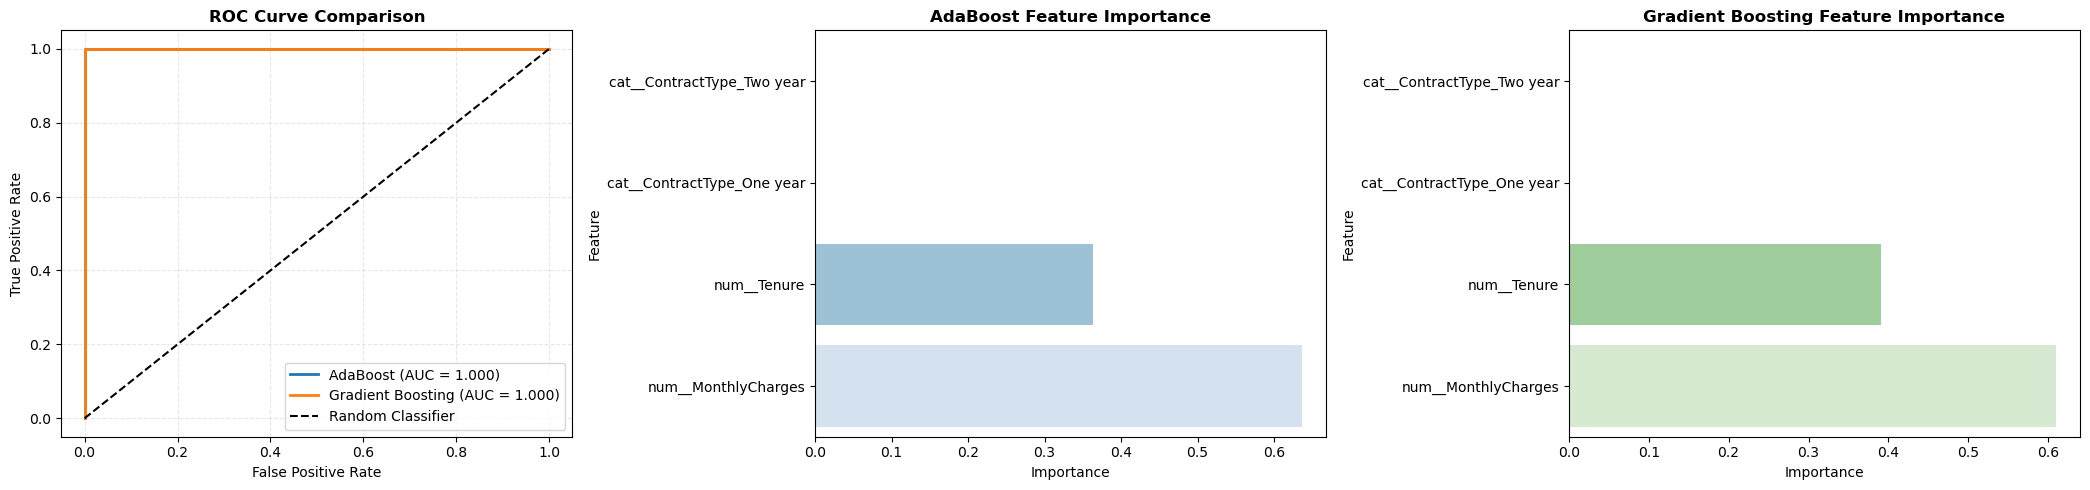


Final Summary
AdaBoost Accuracy: 1.0000 (100.00%)
Gradient Boosting Accuracy: 1.0000 (100.00%)
AdaBoost ROC AUC: 1.0000
Gradient Boosting ROC AUC: 1.0000
Accuracy Improvement: +0.00%
ROC AUC Improvement: +0.00%


In [4]:
from sklearn.metrics import roc_curve
import numpy as np

comparison_df = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting'],
    'Accuracy': [ada_accuracy, gb_accuracy],
    'ROC AUC': [ada_auc, gb_auc]
})

print('Model Comparison')
print('=' * 60)
print(comparison_df.to_string(index=False))
print('\nBest model by accuracy:', comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model'])
print('Best model by ROC AUC:', comparison_df.loc[comparison_df['ROC AUC'].idxmax(), 'Model'])

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_probabilities)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probabilities)

feature_names = gb_model.named_steps['preprocessor'].get_feature_names_out()
ada_importances = ada_model.named_steps['model'].feature_importances_
gb_importances = gb_model.named_steps['model'].feature_importances_

ada_feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ada_importances
}).sort_values('Importance', ascending=False).head(10)

gb_feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importances
}).sort_values('Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {ada_auc:.3f})', linewidth=2)
axes[0].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {gb_auc:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3, linestyle='--')

sns.barplot(data=ada_feature_df.iloc[::-1], x='Importance', y='Feature', ax=axes[1], palette='Blues_r')
axes[1].set_title('AdaBoost Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

sns.barplot(data=gb_feature_df.iloc[::-1], x='Importance', y='Feature', ax=axes[2], palette='Greens_r')
axes[2].set_title('Gradient Boosting Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance')
axes[2].set_ylabel('Feature')

plt.tight_layout()
plt.show()

print('\nFinal Summary')
print('=' * 60)
print(f'AdaBoost Accuracy: {ada_accuracy:.4f} ({ada_accuracy * 100:.2f}%)')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.4f} ({gb_accuracy * 100:.2f}%)')
print(f'AdaBoost ROC AUC: {ada_auc:.4f}')
print(f'Gradient Boosting ROC AUC: {gb_auc:.4f}')
print(f'Accuracy Improvement: {(gb_accuracy - ada_accuracy) * 100:+.2f}%')
print(f'ROC AUC Improvement: {(gb_auc - ada_auc) * 100:+.2f}%')

## Scenario 3: Random Forest for Income Prediction
Predict whether a person earns more than 50K using a Random Forest classifier.

**Dataset:** `D:\SEM4\ml\lab\dataset\6th\income_random_forest.csv`

**Target Variable:** Income (`>50K` or `<=50K`)

**Input Features:** Age, Education, Occupation, Hours-per-week

**Tasks:**
- Train Random Forest
- Tune number of trees
- Evaluate model
- Visualize feature importance
- Plot accuracy vs number of trees

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

income_path = r'D:\SEM4\ml\lab\dataset\6th\income_random_forest.csv'
df_income = pd.read_csv(income_path)

print('First 5 rows of the income dataset:')
print(df_income.head())
print('\n' + '=' * 60 + '\n')
print(f'Dataset Shape: {df_income.shape}')
print('\nColumns:')
print(df_income.columns.tolist())
print('\nMissing Values:')
print(df_income.isnull().sum())


def resolve_column(columns, candidates):
    normalized_map = {
        str(column).strip().lower().replace(' ', '').replace('-', '').replace('_', ''): column
        for column in columns
    }
    for candidate in candidates:
        normalized_candidate = candidate.strip().lower().replace(' ', '').replace('-', '').replace('_', '')
        if normalized_candidate in normalized_map:
            return normalized_map[normalized_candidate]
    raise KeyError(f'Could not find any of the columns: {candidates}')


age_col = resolve_column(df_income.columns, ['age'])
education_col = resolve_column(df_income.columns, ['education', 'educationyears', 'education years', 'years of education'])
hours_col = resolve_column(df_income.columns, ['hoursperweek', 'hours-per-week', 'hours per week'])

experience_col = None
for candidate in ['experience', 'workexperience', 'work experience']:
    try:
        experience_col = resolve_column(df_income.columns, [candidate])
        break
    except KeyError:
        continue

categorical_col = None
for candidate in ['occupation', 'job', 'contracttype']:
    try:
        categorical_col = resolve_column(df_income.columns, [candidate])
        break
    except KeyError:
        continue

target_col = None
for candidate in ['income', 'salary', 'target', 'class']:
    try:
        target_col = resolve_column(df_income.columns, [candidate])
        break
    except KeyError:
        continue

if target_col is None:
    raise KeyError('Could not find the income target column.')

feature_cols = [age_col, education_col, hours_col]
if experience_col is not None:
    feature_cols.append(experience_col)
if categorical_col is not None:
    feature_cols.append(categorical_col)

required_cols = feature_cols + [target_col]
df_income = df_income.dropna(subset=required_cols).copy()

for numeric_col in [age_col, education_col, hours_col, experience_col]:
    if numeric_col is not None and numeric_col in df_income.columns:
        df_income[numeric_col] = pd.to_numeric(df_income[numeric_col], errors='coerce')

df_income = df_income.dropna(subset=[col for col in [age_col, education_col, hours_col, experience_col] if col is not None]).copy()

X = df_income[feature_cols].copy()
target_series = df_income[target_col]

if pd.api.types.is_numeric_dtype(target_series):
    y = target_series.astype(int)
else:
    y = target_series.astype(str).str.strip().str.lower().map({
        '>50k': 1,
        '>50k.': 1,
        '1': 1,
        'true': 1,
        '<=50k': 0,
        '<=50k.': 0,
        '0': 0,
        'false': 0
    })

if y.isnull().any():
    raise ValueError('Target column must contain >50K/<=50K or 0/1 values for income.')

y = y.astype(int)

print('\nFeature sample:')
print(X.head())
print('\nTarget distribution:')
print(y.value_counts())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_income[col])]
categorical_features = [col for col in feature_cols if col not in numeric_features]

if categorical_features:
    try:
        encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', encoder, categorical_features),
        ],
        remainder='drop'
    )
else:
    encoder = None
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
        ],
        remainder='drop'
    )

n_estimators_list = [10, 25, 50, 100, 150, 200]
validation_results = []
trained_models = {}

for n_estimators in n_estimators_list:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=42,
            n_jobs=-1
        ))
    ])
    model.fit(X_train, y_train)
    val_predictions = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)
    validation_results.append((n_estimators, val_accuracy))
    trained_models[n_estimators] = model

results_df = pd.DataFrame(validation_results, columns=['n_estimators', 'validation_accuracy'])
best_n_estimators = int(results_df.loc[results_df['validation_accuracy'].idxmax(), 'n_estimators'])
best_validation_accuracy = float(results_df['validation_accuracy'].max())

print('\nValidation results for different tree counts:')
print(results_df.to_string(index=False))
print(f'\nBest number of trees: {best_n_estimators}')
print(f'Best validation accuracy: {best_validation_accuracy:.4f}')

best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=best_n_estimators,
        random_state=42,
        n_jobs=-1
    ))
])
best_model.fit(X_train_full, y_train_full)

predictions = best_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print('\nRandom Forest Results')
print('=' * 60)
print(f'Accuracy on Test Set: {accuracy:.4f} ({accuracy * 100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, predictions))
print('\nConfusion Matrix:')
print(conf_matrix)

First 5 rows of the income dataset:
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1


Dataset Shape: (120, 5)

Columns:
['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income']

Missing Values:
Age               0
EducationYears    0
HoursPerWeek      0
Experience        0
Income            0
dtype: int64

Feature sample:
   Age  EducationYears  HoursPerWeek  Experience
0   37              12            44          12
1   46              19            58          33
2   53              10            54          24
3   46              11            22           6
4   36              17            56           3

Target distribution:
Income
0    80
1    40
Name: count, dtype: int64

Validat

C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_24632\1499433591.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10).iloc[::-1], x='Importance', y='Feature', ax=axes[0], palette='Oranges_r')


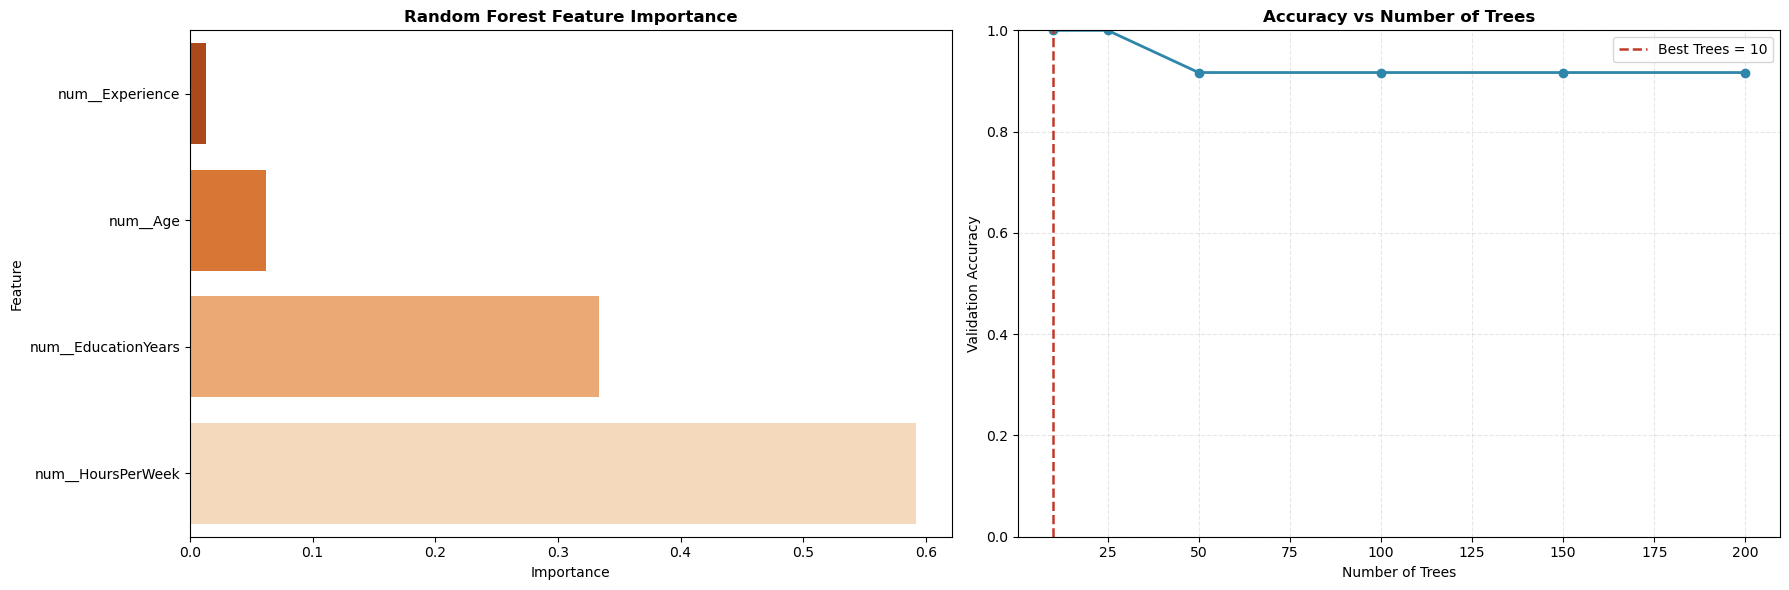


Final Summary
Best Number of Trees: 10
Validation Accuracy at Best Trees: 1.0000
Test Accuracy: 1.0000
Top 5 Important Features:
            Feature  Importance
  num__HoursPerWeek    0.591519
num__EducationYears    0.333541
           num__Age    0.061988
    num__Experience    0.012953


In [7]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_importances = best_model.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

after_merge = results_df.sort_values('n_estimators')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=importance_df.head(10).iloc[::-1], x='Importance', y='Feature', ax=axes[0], palette='Oranges_r')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

axes[1].plot(after_merge['n_estimators'], after_merge['validation_accuracy'], marker='o', linewidth=2, color='#2E86AB')
axes[1].axvline(best_n_estimators, color='#C0392B', linestyle='--', linewidth=1.8, label=f'Best Trees = {best_n_estimators}')
axes[1].set_title('Accuracy vs Number of Trees', fontweight='bold')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nFinal Summary')
print('=' * 60)
print(f'Best Number of Trees: {best_n_estimators}')
print(f'Validation Accuracy at Best Trees: {best_validation_accuracy:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')
print('Top 5 Important Features:')
print(importance_df.head(5).to_string(index=False))

## Scenario 4: Stacking for Heart Disease Prediction
Predict heart disease presence using individual classifiers and a StackingClassifier.

**Dataset:** `D:\SEM4\ml\lab\dataset\6th\heart_stacking.csv`

**Target Variable:** Presence of Heart Disease (0/1)

**Input Features:** Cholesterol, Max Heart Rate, Age

**Tasks:**
- Train base models (Logistic Regression, SVM, Decision Tree)
- Combine using StackingClassifier
- Compare with individual models
- Visualize model comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

heart_path = r'D:\SEM4\ml\lab\dataset\6th\heart_stacking.csv'
df_heart = pd.read_csv(heart_path)

print('First 5 rows of heart dataset:')
print(df_heart.head())
print('\n' + '=' * 60 + '\n')
print(f'Dataset Shape: {df_heart.shape}')
print('\nColumns:')
print(df_heart.columns.tolist())
print('\nMissing Values:')
print(df_heart.isnull().sum())


def resolve_column(columns, candidates):
    normalized_map = {
        str(column).strip().lower().replace(' ', '').replace('-', '').replace('_', ''): column
        for column in columns
    }
    for candidate in candidates:
        normalized_candidate = candidate.strip().lower().replace(' ', '').replace('-', '').replace('_', '')
        if normalized_candidate in normalized_map:
            return normalized_map[normalized_candidate]
    raise KeyError(f'Could not find any of the columns: {candidates}')


chol_col = resolve_column(df_heart.columns, ['cholesterol', 'chol'])
hr_col = resolve_column(df_heart.columns, ['maxheartrate', 'max heart rate', 'thalach'])
age_col = resolve_column(df_heart.columns, ['age'])
target_col = resolve_column(df_heart.columns, ['target', 'heartdisease', 'presence', 'output'])

required_cols = [chol_col, hr_col, age_col, target_col]
df_heart = df_heart.dropna(subset=required_cols).copy()

for col in [chol_col, hr_col, age_col, target_col]:
    df_heart[col] = pd.to_numeric(df_heart[col], errors='coerce')

df_heart = df_heart.dropna(subset=required_cols).copy()

df_heart[target_col] = df_heart[target_col].astype(int)
valid_targets = {0, 1}
if not set(df_heart[target_col].unique()).issubset(valid_targets):
    raise ValueError('Target column must contain only 0/1 values for heart disease presence.')

X = df_heart[[chol_col, hr_col, age_col]].copy()
y = df_heart[target_col].copy()

print('\nFeature sample:')
print(X.head())
print('\nTarget distribution:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

decision_tree = DecisionTreeClassifier(random_state=42, max_depth=5)

base_models = {
    'Logistic Regression': log_reg,
    'SVM': svm_model,
    'Decision Tree': decision_tree
}

model_results = []
trained_models = {}

for model_name, model in base_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    model_results.append({'Model': model_name, 'Accuracy': accuracy})
    trained_models[model_name] = model

estimators = [
    ('lr', log_reg),
    ('svm', svm_model),
    ('dt', decision_tree)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
stack_predictions = stack_model.predict(X_test)
stack_accuracy = accuracy_score(y_test, stack_predictions)

model_results.append({'Model': 'StackingClassifier', 'Accuracy': stack_accuracy})
results_df = pd.DataFrame(model_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\nModel Comparison (Accuracy)')
print('=' * 60)
print(results_df.to_string(index=False))

print('\nClassification Report - StackingClassifier')
print('=' * 60)
print(classification_report(y_test, stack_predictions))

First 5 rows of heart dataset:
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0


Dataset Shape: (120, 5)

Columns:
['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease']

Missing Values:
Age             0
Cholesterol     0
MaxHeartRate    0
RestingBP       0
HeartDisease    0
dtype: int64

Feature sample:
   Cholesterol  MaxHeartRate  Age
0          212           189   57
1          266           155   44
2          279           168   59
3          237           123   66
4          221           125   58

Target distribution:
HeartDisease
1    83
0    37
Name: count, dtype: int64

Model Comparison (Accuracy)
              Model  Accuracy
                SVM  0.791667
Logi

C:\Users\PRAVEENGOVIND\AppData\Local\Temp\ipykernel_14780\285485530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Set2', edgecolor='black')


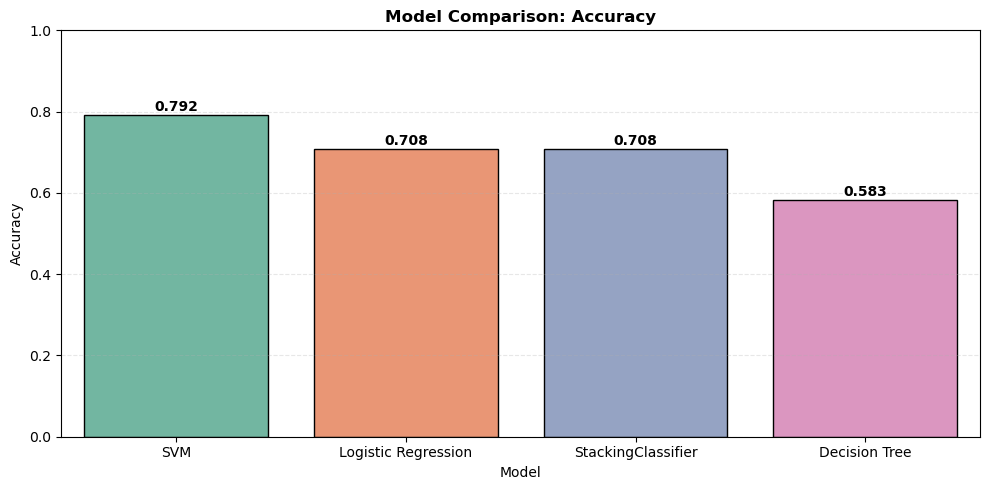


Final Summary
Best Performing Model: SVM
Best Accuracy: 0.7917 (79.17%)
Compared Models: Logistic Regression, SVM, Decision Tree, StackingClassifier


In [2]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Set2', edgecolor='black')

for idx, value in enumerate(results_df['Accuracy']):
    ax.text(idx, value + 0.01, f'{value:.3f}', ha='center', fontweight='bold')

plt.title('Model Comparison: Accuracy', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, 'Model']
best_model_accuracy = results_df.loc[0, 'Accuracy']

print('\nFinal Summary')
print('=' * 60)
print(f'Best Performing Model: {best_model_name}')
print(f'Best Accuracy: {best_model_accuracy:.4f} ({best_model_accuracy * 100:.2f}%)')
print('Compared Models: Logistic Regression, SVM, Decision Tree, StackingClassifier')

## Scenario 5: SMOTE for Fraud Detection
Detect fraudulent transactions using class balancing with SMOTE.
**Target Variable:** Fraud (0 = Normal, 1 = Fraud)
**Input Features:** Transaction Amount, Time, PCA features
**In-Lab Tasks:**
- Check class imbalance
- Apply SMOTE
- Train model before and after SMOTE
- Compare performance

**Visualization:**
- Class distribution before and after SMOTE
- Precision-Recall curve

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

fraud_path = r'D:\SEM4\ml\lab\dataset\6th\fraud_smote.csv'
df_fraud = pd.read_csv(fraud_path)

print('First 5 rows of the fraud dataset:')
print(df_fraud.head())
print('\n' + '=' * 60 + '\n')
print(f'Dataset Shape: {df_fraud.shape}')
print('\nColumns:')
print(df_fraud.columns.tolist())
print('\nMissing Values:')
print(df_fraud.isnull().sum())


def resolve_column(columns, candidates):
    normalized_map = {
        str(column).strip().lower().replace(' ', '').replace('_', '').replace('-', ''): column
        for column in columns
    }
    for candidate in candidates:
        normalized_candidate = candidate.strip().lower().replace(' ', '').replace('_', '').replace('-', '')
        if normalized_candidate in normalized_map:
            return normalized_map[normalized_candidate]
    raise KeyError(f'Could not find any of the columns: {candidates}')


target_col = resolve_column(df_fraud.columns, ['class', 'fraud', 'target'])
feature_cols = [column for column in df_fraud.columns if column != target_col]

for column in feature_cols:
    df_fraud[column] = pd.to_numeric(df_fraud[column], errors='coerce')

df_fraud[target_col] = pd.to_numeric(df_fraud[target_col], errors='coerce')
df_fraud = df_fraud.dropna(subset=feature_cols + [target_col]).copy()
df_fraud[target_col] = df_fraud[target_col].astype(int)

X = df_fraud[feature_cols].copy()
target_series = df_fraud[target_col]

if pd.api.types.is_numeric_dtype(target_series):
    y = target_series.astype(int)
else:
    y = target_series.astype(str).str.strip().str.lower().map({
        '0': 0,
        '1': 1,
        'normal': 0,
        'fraud': 1,
        'no': 0,
        'yes': 1,
        'false': 0,
        'true': 1,
    })

if y.isnull().any():
    raise ValueError('Target column must contain 0/1, Fraud/Normal, or Yes/No values.')

y = y.astype(int)
class_counts = y.value_counts().sort_index().reindex([0, 1], fill_value=0)
imbalance_ratio = class_counts.max() / class_counts.min() if class_counts.min() else np.inf

print('\nClass Distribution in Full Dataset:')
print(class_counts.rename(index={0: 'Normal (0)', 1: 'Fraud (1)'}))
print(f'Imbalance Ratio: {imbalance_ratio:.2f}:1')
print('\nFeature sample:')
print(X.head())
print('\nTarget distribution:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

class_distribution_before = y_train.value_counts().sort_index().reindex([0, 1], fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_probabilities = baseline_model.predict_proba(X_test_scaled)[:, 1]
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_average_precision = average_precision_score(y_test, baseline_probabilities)
baseline_cm = confusion_matrix(y_test, baseline_predictions)

smote = SMOTE(random_state=42)
X_resampled_scaled, y_resampled = smote.fit_resample(X_train_scaled, y_train)
class_distribution_after = pd.Series(y_resampled).value_counts().sort_index().reindex([0, 1], fill_value=0)

smote_model = LogisticRegression(max_iter=2000, random_state=42)
smote_model.fit(X_resampled_scaled, y_resampled)
smote_predictions = smote_model.predict(X_test_scaled)
smote_probabilities = smote_model.predict_proba(X_test_scaled)[:, 1]
smote_accuracy = accuracy_score(y_test, smote_predictions)
smote_average_precision = average_precision_score(y_test, smote_probabilities)
smote_cm = confusion_matrix(y_test, smote_predictions)

comparison_df = pd.DataFrame({
    'Model': ['Before SMOTE', 'After SMOTE'],
    'Accuracy': [baseline_accuracy, smote_accuracy],
    'Average Precision': [baseline_average_precision, smote_average_precision],
})

print('\nBaseline Model Results')
print('=' * 60)
print(f'Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy * 100:.2f}%)')
print(f'Average Precision: {baseline_average_precision:.4f}')
print('\nClassification Report (Before SMOTE):')
print(classification_report(y_test, baseline_predictions))
print('Confusion Matrix (Before SMOTE):')
print(baseline_cm)

print('\nSMOTE Model Results')
print('=' * 60)
print(f'Accuracy: {smote_accuracy:.4f} ({smote_accuracy * 100:.2f}%)')
print(f'Average Precision: {smote_average_precision:.4f}')
print('\nClassification Report (After SMOTE):')
print(classification_report(y_test, smote_predictions))
print('Confusion Matrix (After SMOTE):')
print(smote_cm)

print('\nModel Comparison')
print('=' * 60)
print(comparison_df.to_string(index=False))
print(f'\nAccuracy Improvement after SMOTE: {(smote_accuracy - baseline_accuracy) * 100:+.2f}%')
print(f'Average Precision Improvement after SMOTE: {(smote_average_precision - baseline_average_precision) * 100:+.2f}%')

First 5 rows of the fraud dataset:
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0


Dataset Shape: (120, 5)

Columns:
['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud']

Missing Values:
Amount      0
Time        0
Feature1    0
Feature2    0
Fraud       0
dtype: int64

Class Distribution in Full Dataset:
Fraud
Normal (0)    110
Fraud (1)      10
Name: count, dtype: int64
Imbalance Ratio: 11.00:1

Feature sample:
    Amount   Time  Feature1  Feature2
0  3233.38  34595  2.157308 -0.818199
1  2783.63  73166  1.561511  0.955305
2   923.74  84417 -0.027305 -1.418366
3  2214.14  11139 -0.643518 -0.466037
4   444.75  37847  0.021272 -0.529053

Target distribution:
Fraud
0    110
1     10
Name: count, dtype: int64

Baseline Model Results
Accuracy: 0.9167 (91.67%)
Average Pr

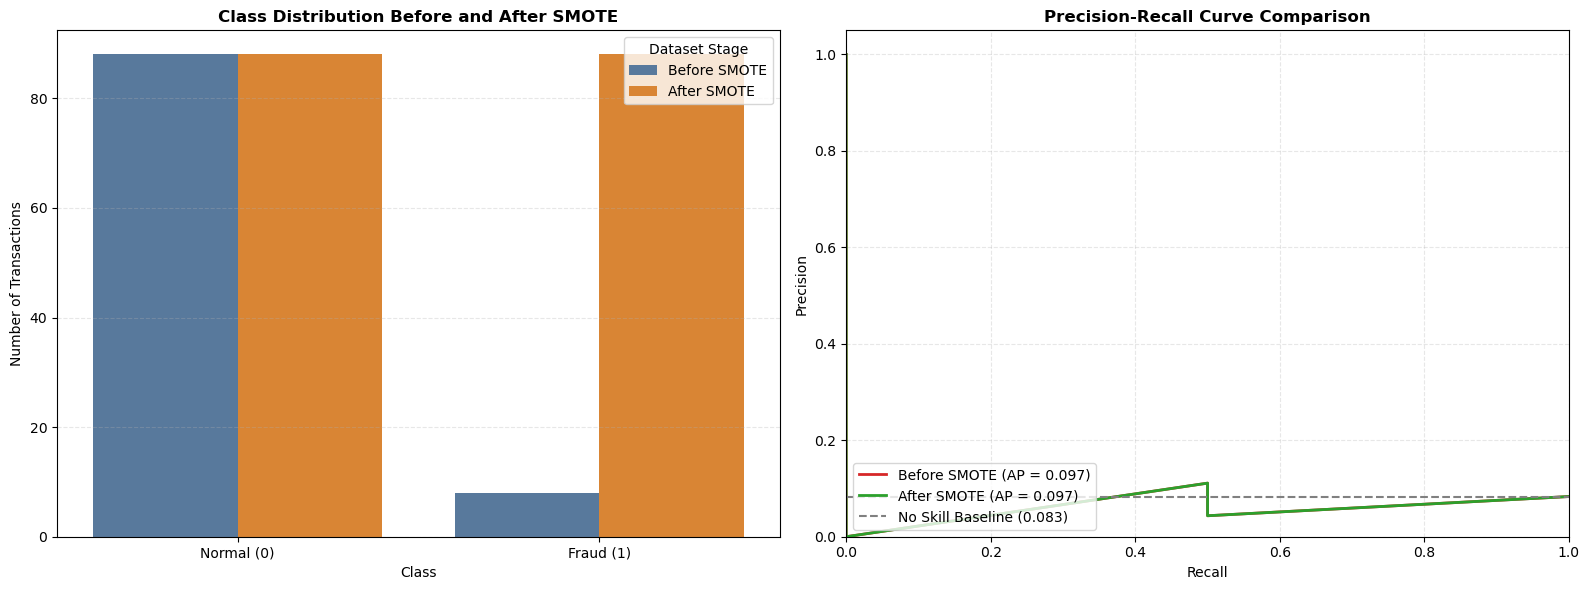


Final Summary
Scenario 5 - SMOTE for Fraud Detection
Total Samples: 120
Training Samples: 96
Testing Samples: 24
Feature Count: 4
Class Imbalance Ratio: 11.00:1

Model Comparison
       Model  Accuracy  Average Precision
Before SMOTE  0.916667           0.097222
 After SMOTE  0.750000           0.097222

Accuracy Improvement after SMOTE: -16.67%
Average Precision Improvement after SMOTE: +0.00%


In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

baseline_precision, baseline_recall, _ = precision_recall_curve(y_test, baseline_probabilities)
smote_precision, smote_recall, _ = precision_recall_curve(y_test, smote_probabilities)

class_distribution_before = y_train.value_counts().sort_index().reindex([0, 1], fill_value=0)
class_distribution_after = pd.Series(y_resampled).value_counts().sort_index().reindex([0, 1], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

distribution_df = pd.DataFrame({
    'Class': ['Normal (0)', 'Fraud (1)'],
    'Before SMOTE': class_distribution_before.values,
    'After SMOTE': class_distribution_after.values,
})
distribution_long = distribution_df.melt(id_vars='Class', var_name='Stage', value_name='Count')

sns.barplot(
    data=distribution_long,
    x='Class',
    y='Count',
    hue='Stage',
    ax=axes[0],
    palette=['#4C78A8', '#F58518']
)
axes[0].set_title('Class Distribution Before and After SMOTE', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Transactions')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend(title='Dataset Stage')

axes[1].plot(
    baseline_recall,
    baseline_precision,
    label=f'Before SMOTE (AP = {baseline_average_precision:.3f})',
    linewidth=2,
    color='#D62728'
)
axes[1].plot(
    smote_recall,
    smote_precision,
    label=f'After SMOTE (AP = {smote_average_precision:.3f})',
    linewidth=2,
    color='#2CA02C'
)
axes[1].axhline(
    y=y_test.mean(),
    linestyle='--',
    color='gray',
    linewidth=1.5,
    label=f'No Skill Baseline ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve Comparison', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

accuracy_improvement = (smote_accuracy - baseline_accuracy) * 100
ap_improvement = (smote_average_precision - baseline_average_precision) * 100

print('\nFinal Summary')
print('=' * 60)
print('Scenario 5 - SMOTE for Fraud Detection')
print('=' * 60)
print(f'Total Samples: {df_fraud.shape[0]}')
print(f'Training Samples: {X_train.shape[0]}')
print(f'Testing Samples: {X_test.shape[0]}')
print(f'Feature Count: {X_train.shape[1]}')
print(f'Class Imbalance Ratio: {imbalance_ratio:.2f}:1')
print('\nModel Comparison')
print(comparison_df.to_string(index=False))
print(f'\nAccuracy Improvement after SMOTE: {accuracy_improvement:+.2f}%')
print(f'Average Precision Improvement after SMOTE: {ap_improvement:+.2f}%')